In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, HDBSCAN
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["soap"])
df = qm9.load()

2026-04-23 13:58:41.507 | INFO     | src.datasets:load:577 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-23 13:58:41.672 | INFO     | src.datasets:_sample_qm9_df:771 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-23 13:58:41.673 | INFO     | src.datasets:_add_requested_descriptors:186 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-23 13:58:41.673 | INFO     | src.features:compute_soap:170 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-23 13:59:15.591 | SUCCESS  | src.datasets:add_soap:925 - Added SOAP embeddings.
2026-04-23 13:59:15.592 | INFO     | src.datasets:_add_requested_descriptors:211 - Added descriptor column(s): ['soap_embedding']
2026-04-23 13:59:15.598 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:664 - Dropped QM9 rows with null/empty descriptor vectors: dropped=14, remaining=5486, descriptor_cols=['soap_embedding'].
2026-04-23 1

In [4]:
molecules = qm9.get_molecules()
len(molecules[0:2])

2026-04-23 13:59:39.784 | SUCCESS  | src.datasets:get_molecules:1289 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


2

In [5]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="soap",
    dist_type="soap_kernel",
    force_calculate=True,
)

2026-04-23 13:59:39.839 | INFO     | src.datasets:get_distance_matrix:1120 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-23 13:59:40.544 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_soap_soap_kernel.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


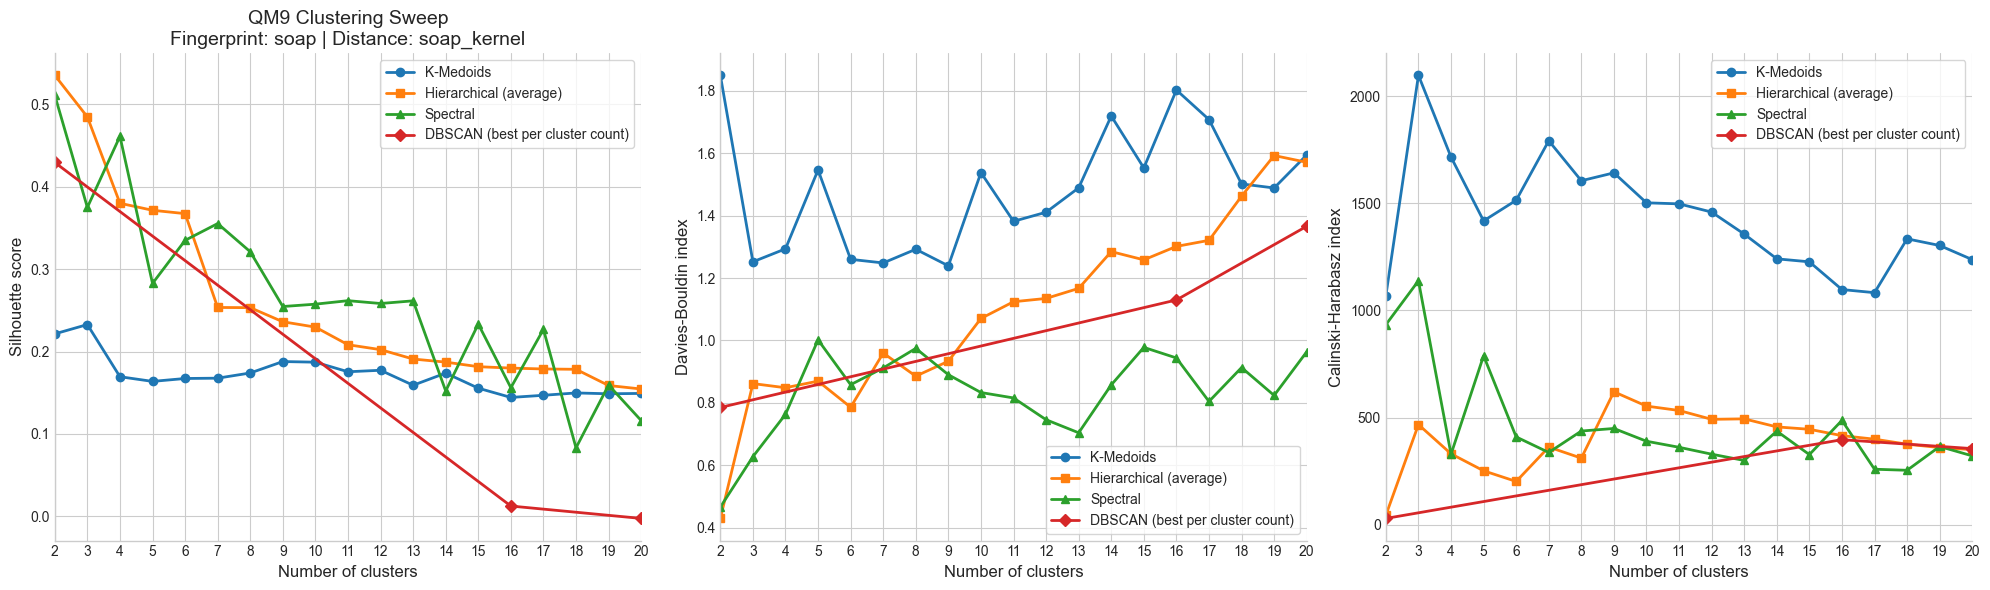

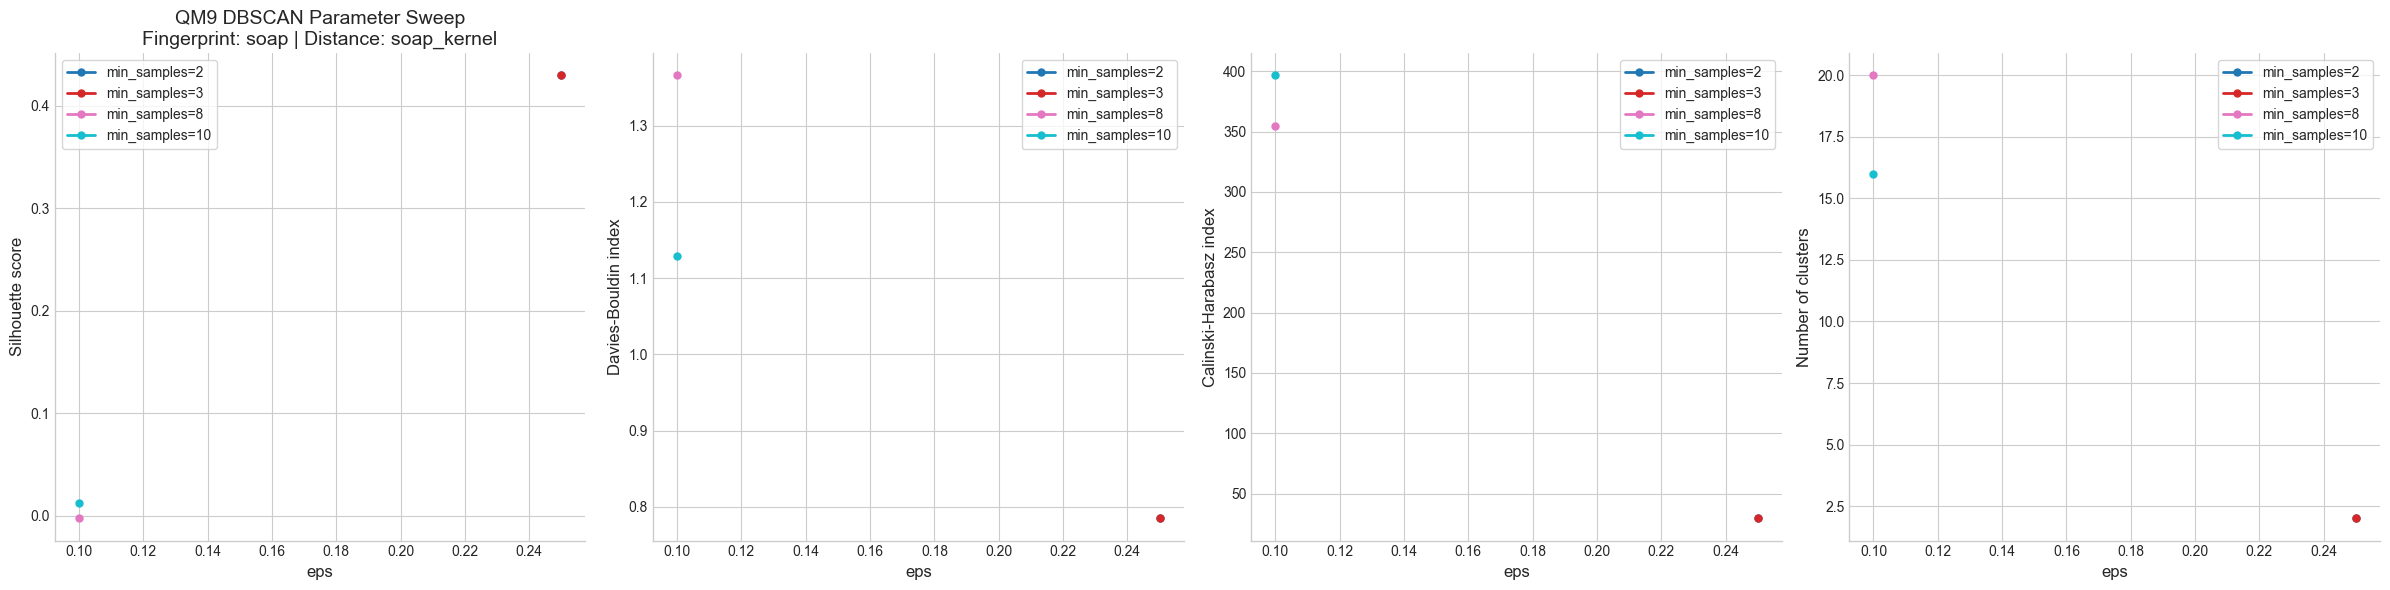

2026-04-23 14:00:44.825 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:841 - Saved clustering sweep plot to figures/qm9/clustering/soap_kernel/soap/clustering_sweep_2_to_20_clusters.png
2026-04-23 14:00:44.826 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved DBSCAN evaluation plot to figures/qm9/clustering/soap_kernel/soap/dbscan_parameter_sweep.png
2026-04-23 14:00:44.826 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:844 - Saved clustering sweep results to figures/qm9/clustering/soap_kernel/soap/clustering_sweep_2_to_20_clusters.json


In [7]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    dataset_name="qm9",
)

In [8]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(3146), np.int64(3148)), (np.int64(102), np.int64(138)), (np.int64(2666), np.int64(2667)), (np.int64(2654), np.int64(2655)), (np.int64(2699), np.int64(2803)), (np.int64(3650), np.int64(3651)), (np.int64(3401), np.int64(3402)), (np.int64(1879), np.int64(1905)), (np.int64(3731), np.int64(3732)), (np.int64(1869), np.int64(1870))]


In [9]:
print(mols[0])

(Atoms(symbols='H9C4HC2H4C3', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H9C4HC2H4C3', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [10]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [32.5, 32.5, 62.5, 62.5],
  [85.0, 85.0, 95.0, 95.0],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [90.0, 90.0, 112.5, 112.5],
  [47.5, 47.5, 101.25, 101.25],
  [10.0, 10.0, 74.375, 74.375],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [165.0, 165.0, 175.0, 175.0],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [170.0, 170.0, 192.5, 192.5],
  [142.5, 142.5, 181.25, 181.25],
  [215.0, 215.0, 225.0, 225.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [243.75, 243.75, 282.5, 282.5],
  [220.0, 220.0, 263.125, 263.125],
  [161.875, 161.875, 241.5625, 241.5625],
  [42.1875, 42.1875, 201.71875, 201.71875]],
 'dcoord': [[0.0,
   np.float64(0.7222951650619507),
   np.floa

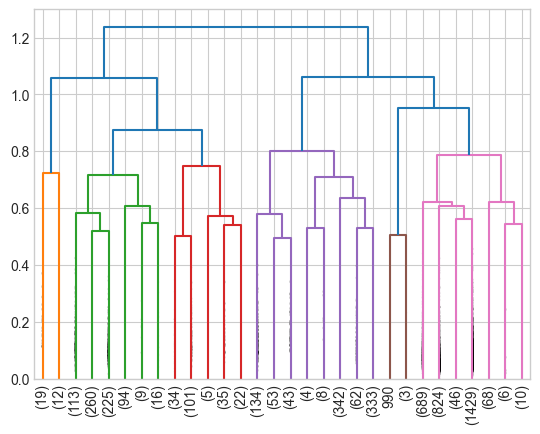

In [11]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show the last 30 merges
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

In [12]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1]), array([4055,  945]))


In [13]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [14]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-23 14:01:09.684 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png


{'coords': array([[ 8.6520815 , -3.6760607 ],
        [12.075037  , -0.86880934],
        [21.564516  ,  3.4664602 ],
        ...,
        [-3.2970293 , -1.8225847 ],
        [ 7.496525  , -8.740057  ],
        [ 4.549474  , -5.7921047 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [15]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (2, 67)
┌─────────────┬───────┬─────────────────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬──────────────┬──────────────────┬──────────────────────────┬──────────────────────┬───────────────────

# KMedoids

In [16]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([ 957, 2135, 1908]))


In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-23 14:01:29.887 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png


{'coords': array([[ 8.6520815 , -3.6760607 ],
        [12.075037  , -0.86880934],
        [21.564516  ,  3.4664602 ],
        ...,
        [-3.2970293 , -1.8225847 ],
        [ 7.496525  , -8.740057  ],
        [ 4.549474  , -5.7921047 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

In [19]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 68)
┌───────────┬───────┬─────────────────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬──────────────┬──────────────────┬────────────────────────┬──────────────────────┬─────────

labels_km,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64
0,957,1.924329,120.353187,-0.296761,55.034483,0.652492,12.97425,8.653083,1.185998,0.420063,0.010449,3.38976,16.22675,2.019116,1.998955,0.106006,0.430383,0.463611,1.480669,2.543365,6.052247,0.606061,2.164054,2.493208,6.399164,31.557994,1.256018,0.00209,0.133751,0.084639,0.430512,0.316614,0.005225,0.016719,0.059561,0.205852,0.001045,3.373221,72.281641,-6.340924,-0.216426,6.124518,1167.893621,3.396194,-11221.956392,-11221.732288,-11221.706611,-11222.86244,29.935458,-68.18912,-68.574368,-68.955013,-63.552396,3.955642,1.409393,1.068309,0.763845,44.30512,40.543365,15.151515,31.557994,333,"""Acyclic""",15.151515,81,"""C1CCCC1""",25.600836
1,2135,2.147218,122.152693,0.376581,23.746604,0.886771,12.786241,8.833255,1.963466,0.035129,0.001874,1.606557,20.038876,2.086154,2.172834,0.068029,0.12816,0.803811,0.75644,1.241218,7.263232,0.496019,0.91007,5.820609,6.311944,43.178923,1.262745,0.001874,0.244965,0.005152,0.064169,0.086183,0.001874,0.007494,0.104918,0.318501,0.0,2.375898,80.172126,-6.46933,0.749204,7.218569,1201.800776,4.580885,-10542.117096,-10541.88209,-10541.856399,-10543.025786,32.886582,-82.495866,-83.019644,-83.499972,-76.74214,3.141514,1.400057,1.145596,0.100234,89.320843,3.466042,7.213115,43.178923,823,"""Acyclic""",7.213115,244,"""C1CC1""",9.601874
2,1908,2.037111,124.203878,-0.068658,39.616876,0.976017,12.81656,8.766247,1.574423,0.045073,0.004717,2.638889,17.930818,2.055169,2.601153,0.054041,0.173076,0.772883,0.835954,2.447065,5.986373,0.343291,1.013103,4.770964,6.33543,36.709119,1.265276,0.001048,0.633124,0.013627,0.060797,0.08805,0.001572,0.091195,0.200734,0.976939,0.0,2.655028,71.876048,-6.714508,0.235448,6.950015,1182.292709,3.963232,-11699.293676,-11699.059256,-11699.033554,-11700.20957,31.767314,-74.880697,-75.331827,-75.763303,-69.68147,3.322424,1.394557,1.126985,0.0,82.651992,4.454927,12.893082,36.709119,611,"""Acyclic""",12.893082,216,"""Acyclic""",12.893082


# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4998,    1,    1]))


In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-23 14:03:17.301 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png


{'coords': array([[ 8.6520815 , -3.6760607 ],
        [12.075037  , -0.86880934],
        [21.564516  ,  3.4664602 ],
        ...,
        [-3.2970293 , -1.8225847 ],
        [ 7.496525  , -8.740057  ],
        [ 4.549474  , -5.7921047 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'spectral'}

In [23]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 69)
┌─────────────────┬───────┬────────────────────┬────────────┬────────┬─────────┬───────────────────┬────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬───────────────┬──────────────────┬───────────────────┬───────────────────┬─────

labels_spectral,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64
0,4998,2.06246,122.601641,0.077031,35.805522,0.87596,12.833834,8.77391,1.666066,0.112645,0.004602,2.342737,18.504602,2.061482,2.303721,0.069988,0.203227,0.726786,0.92577,1.951381,6.544018,0.458984,1.189876,4.782313,6.337735,38.483994,1.262423,0.001601,0.371949,0.023609,0.133053,0.131052,0.002401,0.041216,0.132853,0.548419,0.0002,2.674334,75.498031,-6.538049,0.367551,6.90564,1188.038961,4.118203,-11115.283246,-11115.05053,-11115.024838,-11116.19421,31.896795,-76.851519,-77.321028,-77.763627,-71.523219,3.365718,1.399428,1.123361,0.189076,1.190276,78.151261,10.944378,10.904362,38.483994,1497,"""Acyclic""",10.904362,316,"""Acyclic""",10.904362
1,1,2.263158,96.0,2.0,0.0,0.941325,12.737012,7.0,2.0,0.0,0.0,0.0,19.0,2.105263,1.0,0.0,0.0,1.0,0.0,0.0,7.0,0.0,0.0,7.0,6.0,43.0,1.263386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1661,70.400002,-7.094008,2.255824,9.349833,746.341614,4.707679,-7449.425781,-7449.240723,-7449.214844,-7450.260254,26.556999,-77.026627,-77.573761,-78.036469,-71.611641,4.58166,2.38671,1.97469,0.0,1.0,100.0,0.0,0.0,43.0,1,"""C1CC2CCC12""",100.0,1,"""C1CC2CCC12""",100.0
2,1,2.263158,96.0,2.0,0.0,0.941325,12.737012,7.0,2.0,0.0,0.0,0.0,19.0,2.105263,0.0,0.0,0.0,1.0,0.0,0.0,7.0,0.0,0.0,7.0,6.0,43.0,1.264835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0187,70.959999,-7.303536,2.391881,9.695416,768.271301,4.708467,-7449.515625,-7449.332031,-7449.306152,-7450.345703,26.382,-77.116043,-77.66481,-78.127518,-71.697571,5.42719,1.99804,1.97557,0.0,1.0,100.0,0.0,0.0,43.0,1,"""C1CC2(C1)CCC2""",100.0,1,"""C1CC2(C1)CCC2""",100.0


# DBSCAN 

In [24]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([0, 1]), array([4996,    4]))


In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-23 14:03:38.589 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_dbscan_projection.png


{'coords': array([[ 8.6520815 , -3.6760607 ],
        [12.075037  , -0.86880934],
        [21.564516  ,  3.4664602 ],
        ...,
        [-3.2970293 , -1.8225847 ],
        [ 7.496525  , -8.740057  ],
        [ 4.549474  , -5.7921047 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [27]:
d =average_numeric_by_cluster(df, "labels_db")

shape: (2, 70)
┌───────────┬───────┬───────────────────┬────────────┬────────┬─────────┬───────────────────┬───────────────────┬─────────────────┬───────────┬───────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬──────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬──────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬──────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬──────────────┬──────────────────┬──────────────────┬──────────────────┬────

# HDBSCAN

In [28]:
import numpy as np
import hdbscan
dist_matrix = dist_matrix.astype(np.float64)
def evaluate_hdbscan(dist_matrix, min_cluster_size, min_samples, method='eom'):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='precomputed',
        cluster_selection_method=method
    )
    
    labels = clusterer.fit_predict(dist_matrix)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = np.mean(labels == -1)
    
    if n_clusters > 0:
        avg_persistence = np.mean(clusterer.cluster_persistence_)
    else:
        avg_persistence = 0
    
    return {
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "noise": noise_frac,
        "persistence": avg_persistence,
        "labels": labels
    }

results = []

for mcs in [20, 40, 80, 150, 300]:
    for ms in [1, 10, 40, None]:
        if ms is None:
            ms = mcs  # conservative default
        
        res = evaluate_hdbscan(dist_matrix, mcs, ms)
        results.append(res)

# Sort by something meaningful
results_sorted = sorted(results, key=lambda x: (-x["persistence"], x["noise"]))

for r in results_sorted[:10]:
    print(
        f"mcs={r['min_cluster_size']}, "
        f"ms={r['min_samples']}, "
        f"clusters={r['clusters']}, "
        f"noise={r['noise']:.2f}, "
        f"persistence={r['persistence']:.3f}"
    )

mcs=150, ms=1, clusters=8, noise=0.19, persistence=0.213
mcs=300, ms=1, clusters=7, noise=0.22, persistence=0.191
mcs=300, ms=10, clusters=4, noise=0.52, persistence=0.186
mcs=80, ms=1, clusters=12, noise=0.11, persistence=0.178
mcs=150, ms=10, clusters=7, noise=0.35, persistence=0.150
mcs=40, ms=1, clusters=15, noise=0.09, persistence=0.144
mcs=80, ms=10, clusters=10, noise=0.33, persistence=0.120
mcs=40, ms=10, clusters=12, noise=0.30, persistence=0.115
mcs=80, ms=40, clusters=6, noise=0.60, persistence=0.106
mcs=20, ms=1, clusters=17, noise=0.10, persistence=0.105


In [29]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=150,
        min_samples=1,
        metric='precomputed',
    )
    
labels = clusterer.fit_predict(dist_matrix)

In [30]:
create_chemiscope_viewer(df, dist_matrix, labels, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

# KMeans

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = np.array(df['soap_embedding'].to_list())
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X_pca)
df = df.with_columns(labels_kmeans=labels_kmeans)

print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1707, 1401, 1892]))


In [32]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [33]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 71)
┌───────────────┬───────┬─────────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────┬─────────────────┬─────────────────┬──────────────┬─────────────────┬─────────────────┬─────────────────┬───

labels_kmeans,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64
0,1707,2.165253,121.702402,0.541301,19.36321,0.90438,12.755984,8.838899,2.158172,0.022847,0.000586,1.344464,20.275923,2.103806,1.997657,0.063133,0.114094,0.822773,0.608084,1.063855,7.432337,0.47686,0.852958,6.164616,6.250146,44.039836,1.265527,0.002343,0.217926,0.001172,0.031634,0.04628,0.0,0.001757,0.094903,0.328647,0.0,2.123764,81.074622,-6.468516,0.901448,7.370001,1176.358239,4.680935,-10371.406255,-10371.174518,-10371.148821,-10372.307902,32.816089,-83.832631,-84.371385,-84.859521,-77.9865,3.085452,1.440888,1.184132,0.069127,1.013474,0.001757,0.0,93.438781,2.28471,4.276508,44.039836,718,"""C1CC1""",5.33099,231,"""C1CC1""",7.850029
1,1401,1.9583,120.261956,-0.214133,49.656674,0.709379,12.947018,8.620271,1.085653,0.322627,0.009279,3.093505,16.981442,2.007204,2.359743,0.113829,0.350981,0.535191,1.334761,2.33262,6.045682,0.683084,1.817987,3.025696,6.55389,33.610992,1.252988,0.001428,0.167024,0.066381,0.361884,0.279086,0.003569,0.019986,0.077088,0.279086,0.000714,3.229085,73.320642,-6.415295,-0.075112,6.340218,1223.473802,3.613192,-11095.853903,-11095.621367,-11095.595697,-11096.772545,30.84575,-70.48909,-70.893417,-71.292416,-65.665569,4.004936,1.345724,1.043118,0.589579,0.426124,0.0,0.000714,48.465382,31.192006,20.342612,33.610992,393,"""Acyclic""",20.342612,92,"""C1CCCC1""",22.19843
2,1892,2.047059,125.117336,-0.124207,40.345666,0.973739,12.820158,8.827167,1.65222,0.038055,0.004757,2.684989,18.034884,2.063534,2.536469,0.043635,0.17402,0.782345,0.908562,2.467759,6.112051,0.276427,1.027484,4.838266,6.256342,37.084567,1.26661,0.001057,0.662262,0.012156,0.054968,0.09778,0.0037,0.092495,0.208245,0.94556,0.0,2.757555,72.073953,-6.692379,0.215712,6.90814,1171.883208,3.985072,-11796.935945,-11796.702266,-11796.67656,-11797.849547,31.839937,-75.264543,-75.719929,-76.153749,-70.029565,3.146979,1.402627,1.12885,0.000529,1.915433,0.0,0.001586,86.363636,3.752643,9.883721,37.084567,677,"""Acyclic""",9.883721,220,"""C1CC1""",10.412262
